In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, math, cv2, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.cuda.amp import GradScaler, autocast
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from einops import rearrange
from tqdm.auto import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from collections import defaultdict
import warnings
import torchvision.models as models
warnings.filterwarnings('ignore')

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available else 'cpu')
print(device)

cuda


In [ ]:
class Config:
    data_dir = "/content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Datasets/Datasets/module4"
    annotation_file = "labels.txt"
    train_split = 0.9

    img_size = (64, 192)
    in_channels = 3

    # Model settings
    embed_dim = 256
    num_heads = 8
    dec_depth = 1
    mlp_ratio = 4.0
    dropout = 0.1

    # Training settings
    batch_size = 64
    num_workers = 0
    epochs = 100
    lr = 1e-4
    weight_decay = 0.01
    warmup_epochs = 5
    label_smoothing = 0.1

    chars = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"
    max_label_len = 10
    patience = 20
    save_dir = "/content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Training/Module_4/Checkpoints"

config = Config()

In [ ]:
class Tokenizer:
    BOS, EOS, PAD = '[B]', '[E]', '[P]'
    def __init__(self, chars):
        self.itos = [self.EOS, self.BOS, self.PAD] + list(chars)
        self.stoi = {s: i for i, s in enumerate(self.itos)}
    @property
    def eos_id(self): return 0
    @property
    def bos_id(self): return 1
    @property
    def pad_id(self): return 2
    @property
    def num_classes(self): return len(self.itos)
    def encode(self, text, max_len):
        ids = [self.bos_id] + [self.stoi.get(c, self.pad_id) for c in text.upper() if c in self.stoi] + [self.eos_id]
        ids = ids[:max_len + 2]
        return torch.tensor(ids + [self.pad_id] * (max_len + 2 - len(ids)), dtype=torch.long)
    def decode(self, ids):
        chars = []
        for i in ids.tolist():
            if i == self.eos_id: break
            if i not in [self.bos_id, self.pad_id] and i < len(self.itos):
                chars.append(self.itos[i])
        return ''.join(chars)

tokenizer = Tokenizer(config.chars)
print(f"Vocab size: {tokenizer.num_classes}")

Vocab size: 39


In [ ]:
class ImageProcessor:
    @staticmethod
    def process(img, target_size):
        h, w = target_size

        # 1. Resize & Pad
        oh, ow = img.shape[:2]
        scale = min(w/ow, h/oh)
        nw, nh = int(ow*scale), int(oh*scale)

        img_resized = cv2.resize(img, (nw, nh))

        new_img = np.full((h, w, 3), 0, dtype=np.uint8)

        y, x = (h-nh)//2, (w-nw)//2
        new_img[y:y+nh, x:x+nw] = img_resized

        return new_img

In [ ]:
def visualize_preprocessing(img_path, target_size=(64, 192)):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    rgb, edge, binary, gray = ImageProcessor.process(img, target_size)

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes[0, 0].imshow(img); axes[0, 0].set_title('Original')
    axes[0, 1].imshow(rgb); axes[0, 1].set_title('Enhanced + Deskewed + Resized')
    axes[0, 2].imshow(gray, cmap='gray'); axes[0, 2].set_title('Grayscale')
    axes[1, 0].imshow(edge, cmap='gray'); axes[1, 0].set_title('Canny Edges')
    axes[1, 1].imshow(binary, cmap='gray'); axes[1, 1].set_title('Adaptive Binary')

    # Combined visualization
    combined = np.stack([gray, edge, binary], axis=-1)
    axes[1, 2].imshow(combined); axes[1, 2].set_title('Combined (G+E+B)')

    for ax in axes.flat: ax.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
def load_annotations(data_dir, annotation_file):
    data_dir = Path(data_dir)
    annotations = []
    with open(data_dir / annotation_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2 and (data_dir / parts[0]).exists():
                annotations.append({'image_path': parts[0], 'label': parts[1].upper()})
    print(f"Loaded {len(annotations)} samples")
    return pd.DataFrame(annotations)

In [ ]:
class PlateDataset(Dataset):
    def __init__(self, data_dir, df, tokenizer, img_size, max_len, is_train=True):
        self.data_dir = Path(data_dir)
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.img_size = img_size

        # Augmentation
        if is_train:
            self.aug = A.Compose([
                A.Rotate(limit=10, p=0.5),
                A.RandomBrightnessContrast(p=0.5),
                A.MotionBlur(p=0.2),
                A.GaussNoise(p=0.2),
                A.InvertImg(p=0.1),
            ])
        else:
            self.aug = None

        self.normalize = A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = str(row['label']).upper()

        img_path = self.data_dir / row['image_path']
        img = cv2.imread(str(img_path))

        if img is None:
            img = np.zeros((self.img_size[0], self.img_size[1], 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = ImageProcessor.process(img, self.img_size)

        if self.aug:
            img = self.aug(image=img)['image']

        img = self.normalize(image=img)['image']
        img = img.transpose(2, 0, 1).astype(np.float32)

        return torch.from_numpy(img), self.tokenizer.encode(label, self.max_len), label

In [ ]:
class MultiScaleConvStem(nn.Module):
    def __init__(self, in_channels, embed_dim):
        super().__init__()
        self.rgb_conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1), nn.BatchNorm2d(32), nn.GELU(),
            nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.GELU(),
        )
        self.edge_conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, 2, 1), nn.BatchNorm2d(16), nn.GELU(),
            nn.Conv2d(16, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.GELU(),
        )
        self.binary_conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, 2, 1), nn.BatchNorm2d(16), nn.GELU(),
            nn.Conv2d(16, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.GELU(),
        )
        self.gray_conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, 2, 1), nn.BatchNorm2d(16), nn.GELU(),
            nn.Conv2d(16, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.GELU(),
        )
        self.fusion = nn.Sequential(
            nn.Conv2d(160, embed_dim, 3, 2, 1), nn.BatchNorm2d(embed_dim), nn.GELU(),
            nn.Conv2d(embed_dim, embed_dim, 3, 1, 1), nn.BatchNorm2d(embed_dim), nn.GELU(),
        )

    def forward(self, x):
        rgb = x[:, :3]
        edge = x[:, 3:4]
        binary = x[:, 4:5]
        gray = x[:, 5:6]

        rgb_feat = self.rgb_conv(rgb)
        edge_feat = self.edge_conv(edge)
        binary_feat = self.binary_conv(binary)
        gray_feat = self.gray_conv(gray)

        # Concatenate and fuse
        combined = torch.cat([rgb_feat, edge_feat, binary_feat, gray_feat], dim=1)
        return self.fusion(combined)

In [ ]:
class ResNetEncoder(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        resnet = models.resnet18(pretrained=True)

        self.backbone_conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=3, bias=False)
        self.backbone_conv1.weight = resnet.conv1.weight
        self.backbone_bn1 = resnet.bn1
        self.backbone_relu = resnet.relu

        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2

        self.layer3 = resnet.layer3
        self.layer3[0].conv1.stride = (2, 1)
        self.layer3[0].downsample[0].stride = (2, 1)

        self.layer4 = resnet.layer4
        self.layer4[0].conv1.stride = (2, 1)
        self.layer4[0].downsample[0].stride = (2, 1)


        self.projection = nn.Conv2d(512, embed_dim, kernel_size=1)

        self.pos_embed = nn.Parameter(torch.zeros(1, 1000, embed_dim))
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        x = self.backbone_conv1(x)
        x = self.backbone_bn1(x)
        x = self.backbone_relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.projection(x)

        x = x.flatten(2).transpose(1, 2)

        seq_len = x.size(1)
        x = x + self.pos_embed[:, :seq_len, :]

        return self.dropout(x)

In [ ]:
class PARSeqDecoder(nn.Module):
    def __init__(self, embed_dim, num_heads, depth, mlp_ratio, dropout, num_classes, max_len):
        super().__init__()
        self.token_embed = nn.Embedding(num_classes, embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, max_len + 2, embed_dim))
        self.dropout = nn.Dropout(dropout)

        dec_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, memory, tgt, tgt_mask=None, tgt_pad_mask=None):
        x = self.dropout(self.token_embed(tgt) + self.pos_embed[:, :tgt.size(1)])
        x = self.norm(self.decoder(x, memory, tgt_mask=tgt_mask, tgt_key_padding_mask=tgt_pad_mask))
        return self.head(x)

    def causal_mask(self, sz, device):
        return torch.triu(torch.full((sz, sz), float('-inf'), device=device), diagonal=1)

In [ ]:
class PARSeq(nn.Module):
    def __init__(self, config, tokenizer):
        super().__init__()
        self.tokenizer = tokenizer
        self.max_len = config.max_label_len + 2

        self.encoder = ResNetEncoder(config.embed_dim)

        self.decoder = PARSeqDecoder(
            config.embed_dim, config.num_heads, config.dec_depth,
            config.mlp_ratio, config.dropout, tokenizer.num_classes, config.max_label_len
        )

        for p in self.decoder.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, images, targets=None):
        memory = self.encoder(images)

        if targets is not None:
            tgt_in = targets[:, :-1]
            mask = self.decoder.causal_mask(tgt_in.size(1), images.device)
            pad_mask = (tgt_in == self.tokenizer.pad_id)
            return self.decoder(memory, tgt_in, tgt_mask=mask, tgt_pad_mask=pad_mask)

        return self.generate(memory)

    @torch.no_grad()
    def generate(self, memory):
        B, device = memory.size(0), memory.device
        tgt = torch.full((B, 1), self.tokenizer.bos_id, dtype=torch.long, device=device)

        for _ in range(self.max_len - 1):
            mask = self.decoder.causal_mask(tgt.size(1), device)
            logits = self.decoder(memory, tgt, tgt_mask=mask)

            next_tok = logits[:, -1].argmax(dim=-1, keepdim=True)

            tgt = torch.cat([tgt, next_tok], dim=1)

            if (next_tok == self.tokenizer.eos_id).all(): break

        return tgt

In [ ]:
class History:
    def __init__(self):
        self.data = defaultdict(list)
    def add(self, **kw):
        for k, v in kw.items(): self.data[k].append(v)
    def plot(self, save_path=None):
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes[0,0].plot(self.data['train_loss'], 'b-', lw=2, label='Train')
        axes[0,0].plot(self.data['val_loss'], 'r-', lw=2, label='Val')
        axes[0,0].set_title('Loss'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)
        axes[0,1].plot(self.data['char_acc'], 'g-', lw=2, label='Char Acc')
        axes[0,1].plot(self.data['seq_acc'], 'm-', lw=2, label='Seq Acc')
        axes[0,1].set_title('Accuracy'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)
        axes[1,0].plot(self.data['lr'], 'c-', lw=2)
        axes[1,0].set_title('Learning Rate'); axes[1,0].set_yscale('log'); axes[1,0].grid(True, alpha=0.3)
        if self.data['seq_acc']:
            best_idx = np.argmax(self.data['seq_acc'])
            txt = f"Best Epoch {best_idx+1}:\nSeq Acc: {self.data['seq_acc'][best_idx]*100:.2f}%\nChar Acc: {self.data['char_acc'][best_idx]*100:.2f}%"
            axes[1,1].text(0.5, 0.5, txt, ha='center', va='center', fontsize=14,
                bbox=dict(facecolor='lightgreen', alpha=0.8), transform=axes[1,1].transAxes)
        axes[1,1].axis('off')
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=150)
        plt.show()

In [ ]:
def compute_accuracy(preds, targets, tokenizer):
    correct_chars, total_chars, correct_seqs = 0, 0, 0
    for pred, target in zip(preds, targets):
        pred_text = tokenizer.decode(pred)
        target_text = target if isinstance(target, str) else tokenizer.decode(target)
        if pred_text == target_text: correct_seqs += 1
        min_len = min(len(pred_text), len(target_text))
        for i in range(min_len):
            if pred_text[i] == target_text[i]: correct_chars += 1
        total_chars += max(len(pred_text), len(target_text))
    return correct_chars / max(total_chars, 1), correct_seqs / max(len(preds), 1)

In [ ]:
def visualize_predictions(model, dataset, tokenizer, device, n=8, save_path=None):
    model.eval()
    indices = np.random.choice(len(dataset), min(n, len(dataset)), replace=False)

    cols = 4
    rows = (len(indices) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    if rows == 1: axes = axes[np.newaxis, :]
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        img_tensor, _, label = dataset[idx]

        with torch.no_grad():
            pred = model(img_tensor.unsqueeze(0).to(device))
        pred_text = tokenizer.decode(pred[0])

        rgb = img_tensor.permute(1, 2, 0).numpy()
        rgb = rgb * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        rgb = np.clip(rgb, 0, 1)

        axes[i].imshow(rgb)
        color = 'green' if pred_text == label else 'red'
        axes[i].set_title(f"GT: {label}\nPred: {pred_text}", color=color, fontsize=12, fontweight='bold')
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150)
    plt.show()

In [ ]:
def visualize_channels(dataset, idx=0):
    img_tensor, _, label = dataset[idx]

    rgb = img_tensor.permute(1, 2, 0).numpy()
    rgb = rgb * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    rgb = np.clip(rgb, 0, 1)

    plt.figure(figsize=(6, 3))
    plt.imshow(rgb)
    plt.title(f'Input Image (Tensor) - Label: {label}')
    plt.axis('off')
    plt.show()

In [ ]:
accumulation_steps = 2
def train_epoch(model, loader, optimizer, scheduler, scaler, device, tokenizer, label_smoothing):
    model.train()
    total_loss = 0
    optimizer.zero_grad()

    pbar = tqdm(loader, desc="Training")
    for batch_idx, (images, targets, _) in enumerate(pbar):
        images, targets = images.to(device), targets.to(device)

        with autocast():
            logits = model(images, targets)
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                targets[:, 1:].reshape(-1),
                ignore_index=tokenizer.pad_id,
                label_smoothing=label_smoothing
            )
            loss = loss / accumulation_steps  # Normalize loss

        scaler.scale(loss).backward()

        if (batch_idx + 1) % accumulation_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()

        total_loss += loss.item() * accumulation_steps
        pbar.set_postfix({'loss': f'{loss.item()*accumulation_steps:.4f}', 'lr': f'{scheduler.get_last_lr()[0]:.2e}'})

    return total_loss / len(loader)

@torch.no_grad()
def validate(model, loader, device, tokenizer):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    for images, targets, labels in tqdm(loader, desc="Validating"):
        images, targets = images.to(device), targets.to(device)
        logits = model(images, targets)
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)),
                               targets[:, 1:].reshape(-1), ignore_index=tokenizer.pad_id)
        total_loss += loss.item()
        preds = model.generate(model.encoder(images))
        all_preds.extend(preds.cpu())
        all_labels.extend(labels)
    char_acc, seq_acc = compute_accuracy(all_preds, all_labels, tokenizer)
    return total_loss / len(loader), char_acc, seq_acc

In [ ]:
def main():
    # Load data
    df = load_annotations(config.data_dir, config.annotation_file)
    train_df, val_df = train_test_split(df, train_size=config.train_split, random_state=42)
    print(f"Train: {len(train_df)}, Val: {len(val_df)}")

    # Datasets
    train_ds = PlateDataset(config.data_dir, train_df, tokenizer, config.img_size, config.max_label_len, True)
    val_ds = PlateDataset(config.data_dir, val_df, tokenizer, config.img_size, config.max_label_len, False)
    train_loader = DataLoader(train_ds, config.batch_size, shuffle=True, num_workers=config.num_workers)
    val_loader = DataLoader(val_ds, config.batch_size, shuffle=False, num_workers=config.num_workers)

    # Visualize preprocessing
    print("\nVisualizing preprocessing pipeline...")
    visualize_channels(train_ds, idx=0)

    # Model
    model = PARSeq(config, tokenizer).to(device)
    params = sum(p.numel() for p in model.parameters())
    print(f"Parameters: {params:,}")

    # Optimizer & Scheduler
    optimizer = AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    total_steps = len(train_loader) * config.epochs
    scheduler = OneCycleLR(optimizer, max_lr=config.lr, total_steps=total_steps,
        pct_start=config.warmup_epochs/config.epochs, anneal_strategy='cos',
        div_factor=25, final_div_factor=1000)
    scaler = GradScaler()

    # Training
    os.makedirs(config.save_dir, exist_ok=True)
    history = History()
    best_acc, patience_counter = 0, 0

    for epoch in range(config.epochs):
        print(f"\n{'='*60}\nEpoch {epoch+1}/{config.epochs}\n{'='*60}")

        train_loss = train_epoch(model, train_loader, optimizer, scheduler, scaler,
                                 device, tokenizer, config.label_smoothing)
        val_loss, char_acc, seq_acc = validate(model, val_loader, device, tokenizer)

        history.add(train_loss=train_loss, val_loss=val_loss,
                   char_acc=char_acc, seq_acc=seq_acc, lr=scheduler.get_last_lr()[0])

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Char Acc: {char_acc*100:.2f}% | Seq Acc: {seq_acc*100:.2f}%")

        # Save best
        if seq_acc > best_acc:
            best_acc, patience_counter = seq_acc, 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_acc': best_acc,
                'config': vars(config)
            }, f"{config.save_dir}/best_model.pth")
            print(f"New best: {seq_acc*100:.2f}%")
        else:
            patience_counter += 1

        # Visualize every 20 epochs
        if (epoch + 1) % 20 == 0:
            visualize_predictions(model, val_ds, tokenizer, device,
                                 save_path=f"{config.save_dir}/pred_epoch_{epoch+1}.png")
            history.plot(save_path=f"{config.save_dir}/history_epoch_{epoch+1}.png")

        # Early stopping
        if patience_counter >= config.patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

        # Checkpoint
        if (epoch + 1) % 50 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
            }, f"{config.save_dir}/checkpoint_epoch_{epoch+1}.pth")

    # Final plots
    print("\nFinal Results:")
    history.plot(save_path=f"{config.save_dir}/final_history.png")
    visualize_predictions(model, val_ds, tokenizer, device,
                         save_path=f"{config.save_dir}/final_predictions.png")
    print(f"\nTraining complete! Best Seq Acc: {best_acc*100:.2f}%")

    return model, history

In [ ]:
@torch.no_grad()
def predict(model, image_path, tokenizer, config, device):
    model.eval()

    img = cv2.imread(str(image_path))
    if img is None: return ""
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_processed = ImageProcessor.process(img, config.img_size)

    # Normalize & Tensor
    normalize = A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    img_norm = normalize(image=img_processed)['image']
    img_tensor = torch.from_numpy(img_norm.transpose(2, 0, 1)).float().unsqueeze(0).to(device)

    # Inference
    pred = model(img_tensor)
    return tokenizer.decode(pred[0])

In [ ]:
def predict_with_visualization(model, image_path, tokenizer, config, device):
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    rgb, edge, binary, gray = ImageProcessor.process(img, config.img_size)
    pred_text = predict(model, image_path, tokenizer, config, device)

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes[0, 0].imshow(img); axes[0, 0].set_title('Original')
    axes[0, 1].imshow(rgb); axes[0, 1].set_title('Processed RGB')
    axes[0, 2].imshow(gray, cmap='gray'); axes[0, 2].set_title('Grayscale')
    axes[1, 0].imshow(edge, cmap='gray'); axes[1, 0].set_title('Canny Edges')
    axes[1, 1].imshow(binary, cmap='gray'); axes[1, 1].set_title('Adaptive Binary')
    axes[1, 2].text(0.5, 0.5, f"Prediction:\n{pred_text}", ha='center', va='center',
                    fontsize=24, fontweight='bold', transform=axes[1, 2].transAxes,
                    bbox=dict(facecolor='lightgreen', alpha=0.8))
    axes[1, 2].axis('off')

    for ax in axes.flat[:5]: ax.axis('off')
    plt.tight_layout()
    plt.show()

    return pred_text

In [ ]:
def predict_batch(model, image_paths, tokenizer, config, device, batch_size=32):
    model.eval()
    results = []

    normalize = A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    for i in tqdm(range(0, len(image_paths), batch_size), desc="Predicting"):
        batch_paths = image_paths[i:i+batch_size]
        batch_tensors = []

        for path in batch_paths:
            img = cv2.imread(str(path))
            if img is None:
                img = np.zeros((config.img_size[0], config.img_size[1], 3), dtype=np.uint8)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Process & Normalize
            img = ImageProcessor.process(img, config.img_size)
            img = normalize(image=img)['image']
            img = img.transpose(2, 0, 1).astype(np.float32)
            batch_tensors.append(torch.from_numpy(img))

        batch = torch.stack(batch_tensors).to(device)
        with torch.no_grad():
            preds = model(batch)

        for pred in preds:
            results.append(tokenizer.decode(pred))

    return results

Loaded 965 samples
Train: 868, Val: 97

Visualizing preprocessing pipeline...


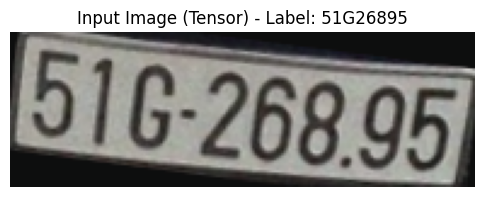

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 132MB/s]


Parameters: 12,640,871

Epoch 1/100


Training:   0%|          | 0/14 [00:00<?, ?it/s]

Validating:   0%|          | 0/2 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/2 [00:00<?, ?it/s]

Train Loss: 1.7842 | Val Loss: 1.2678
Char Acc: 51.71% | Seq Acc: 2.06%

Epoch 20/100


Training:   0%|          | 0/14 [00:00<?, ?it/s]

Validating:   0%|          | 0/2 [00:00<?, ?it/s]

Train Loss: 1.7137 | Val Loss: 1.1282
Char Acc: 52.85% | Seq Acc: 4.12%
New best: 4.12%


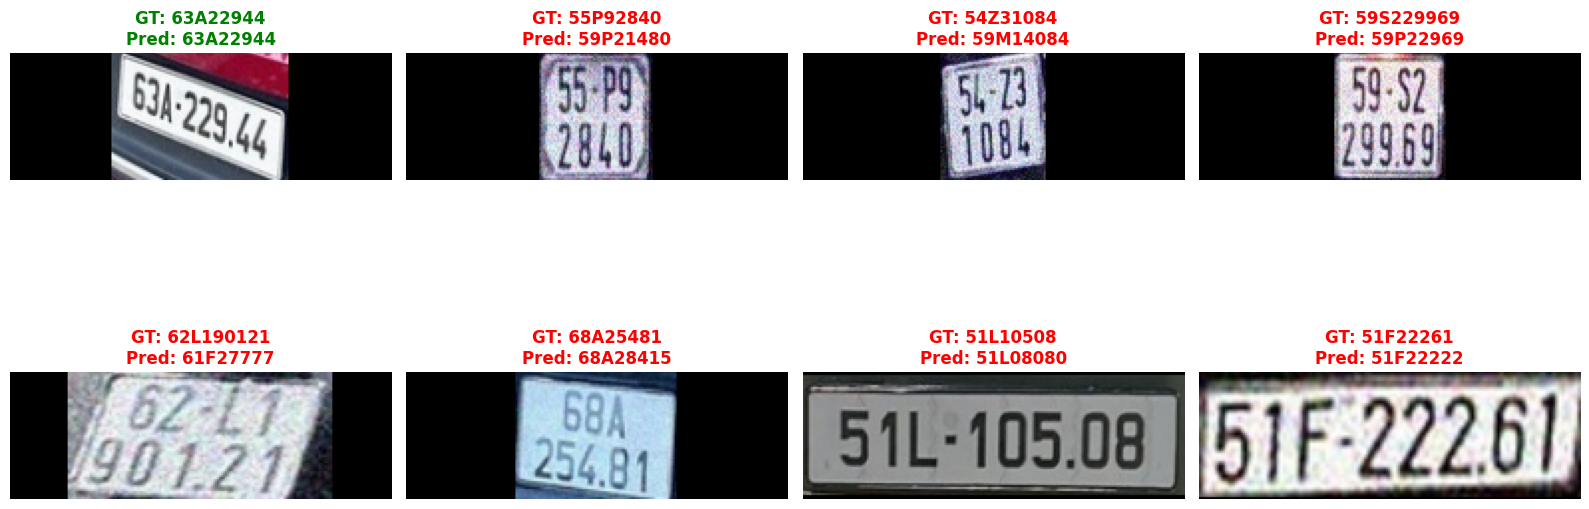

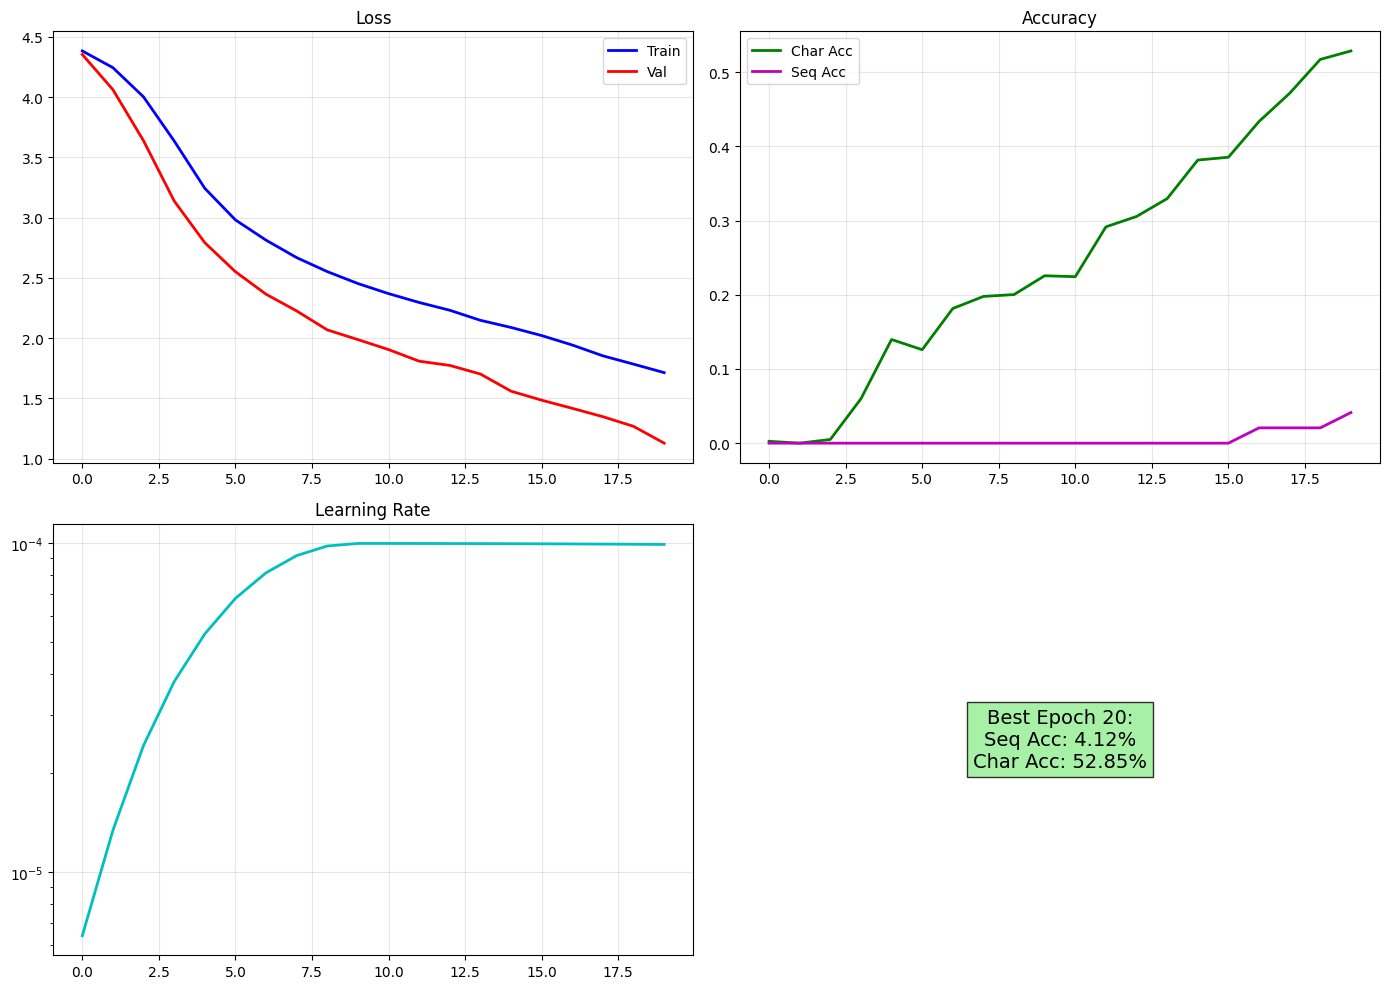


Epoch 21/100


Training:   0%|          | 0/14 [00:00<?, ?it/s]

Validating:   0%|          | 0/2 [00:00<?, ?it/s]

Train Loss: 1.6297 | Val Loss: 1.0590
Char Acc: 55.64% | Seq Acc: 2.06%

Epoch 22/100


Training:   0%|          | 0/14 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/2 [00:00<?, ?it/s]

Train Loss: 0.9324 | Val Loss: 0.3339
Char Acc: 91.38% | Seq Acc: 72.16%
New best: 72.16%

Epoch 40/100


Training:   0%|          | 0/14 [00:00<?, ?it/s]

Validating:   0%|          | 0/2 [00:00<?, ?it/s]

Train Loss: 0.9195 | Val Loss: 0.3349
Char Acc: 91.88% | Seq Acc: 72.16%


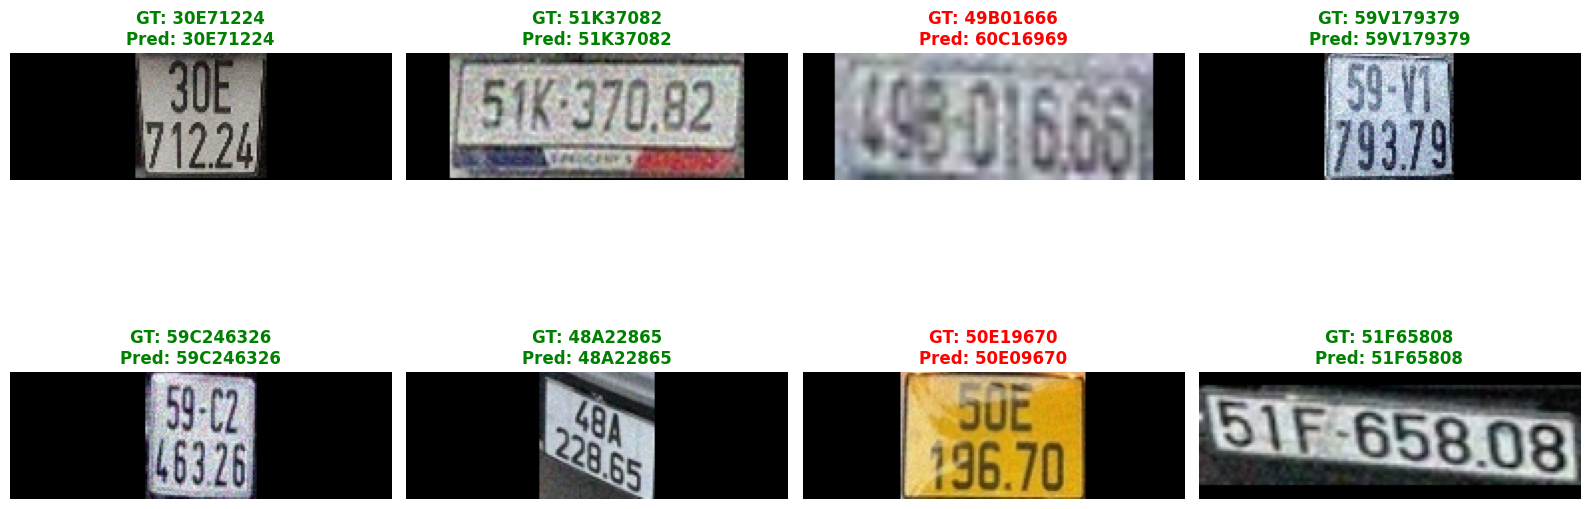

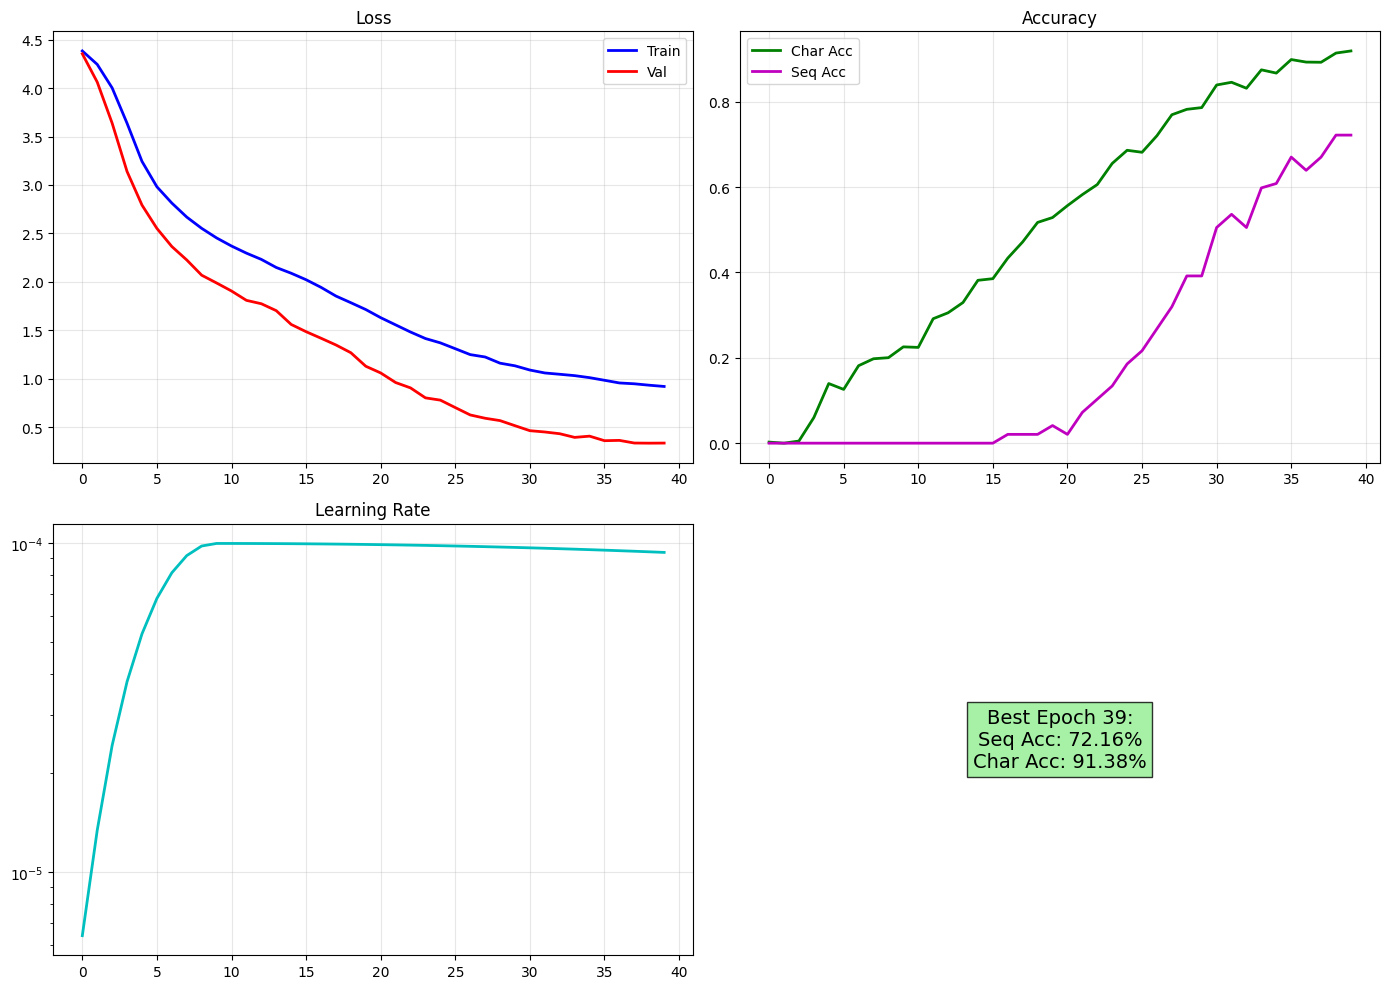


Epoch 41/100


Training:   0%|          | 0/14 [00:00<?, ?it/s]

Validating:   0%|          | 0/2 [00:00<?, ?it/s]

Train Loss: 0.9137 | Val Loss: 0.3106
Char Acc: 91.63% | Seq Acc: 71.13%

Epoch 42/100


Training:   0%|          | 0/14 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/2 [00:00<?, ?it/s]

Train Loss: 0.7895 | Val Loss: 0.2391
Char Acc: 95.06% | Seq Acc: 83.51%
New best: 83.51%

Epoch 60/100


Training:   0%|          | 0/14 [00:00<?, ?it/s]

Validating:   0%|          | 0/2 [00:00<?, ?it/s]

Train Loss: 0.8124 | Val Loss: 0.2304
Char Acc: 94.55% | Seq Acc: 81.44%


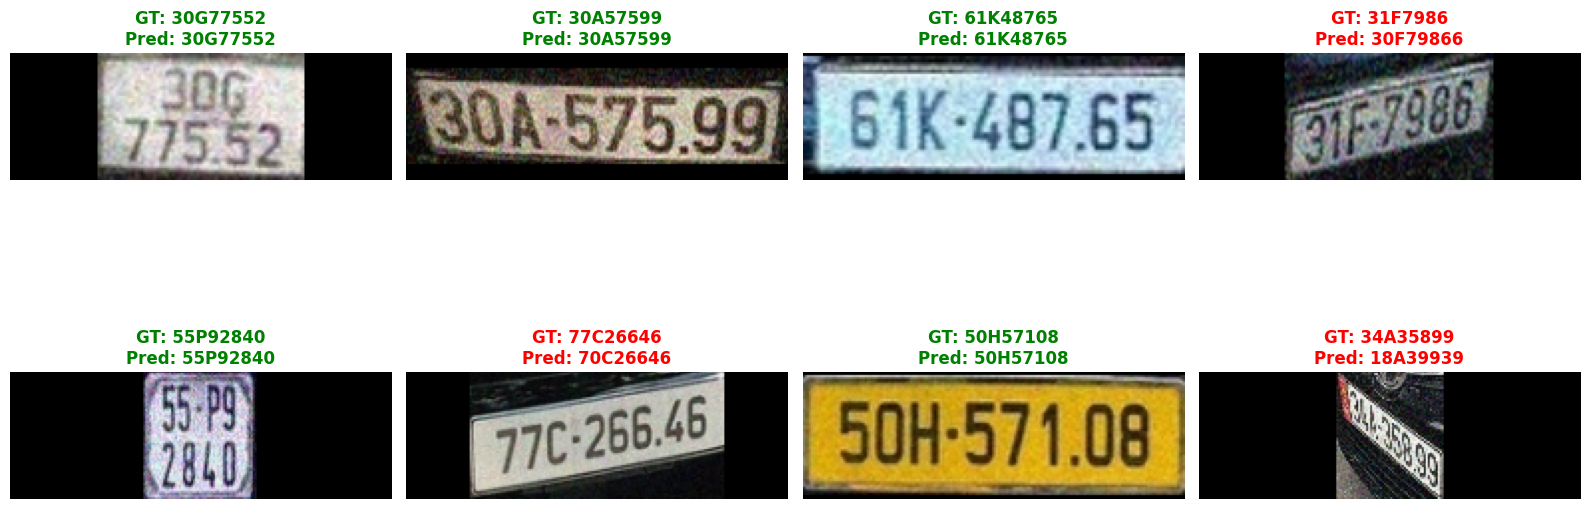

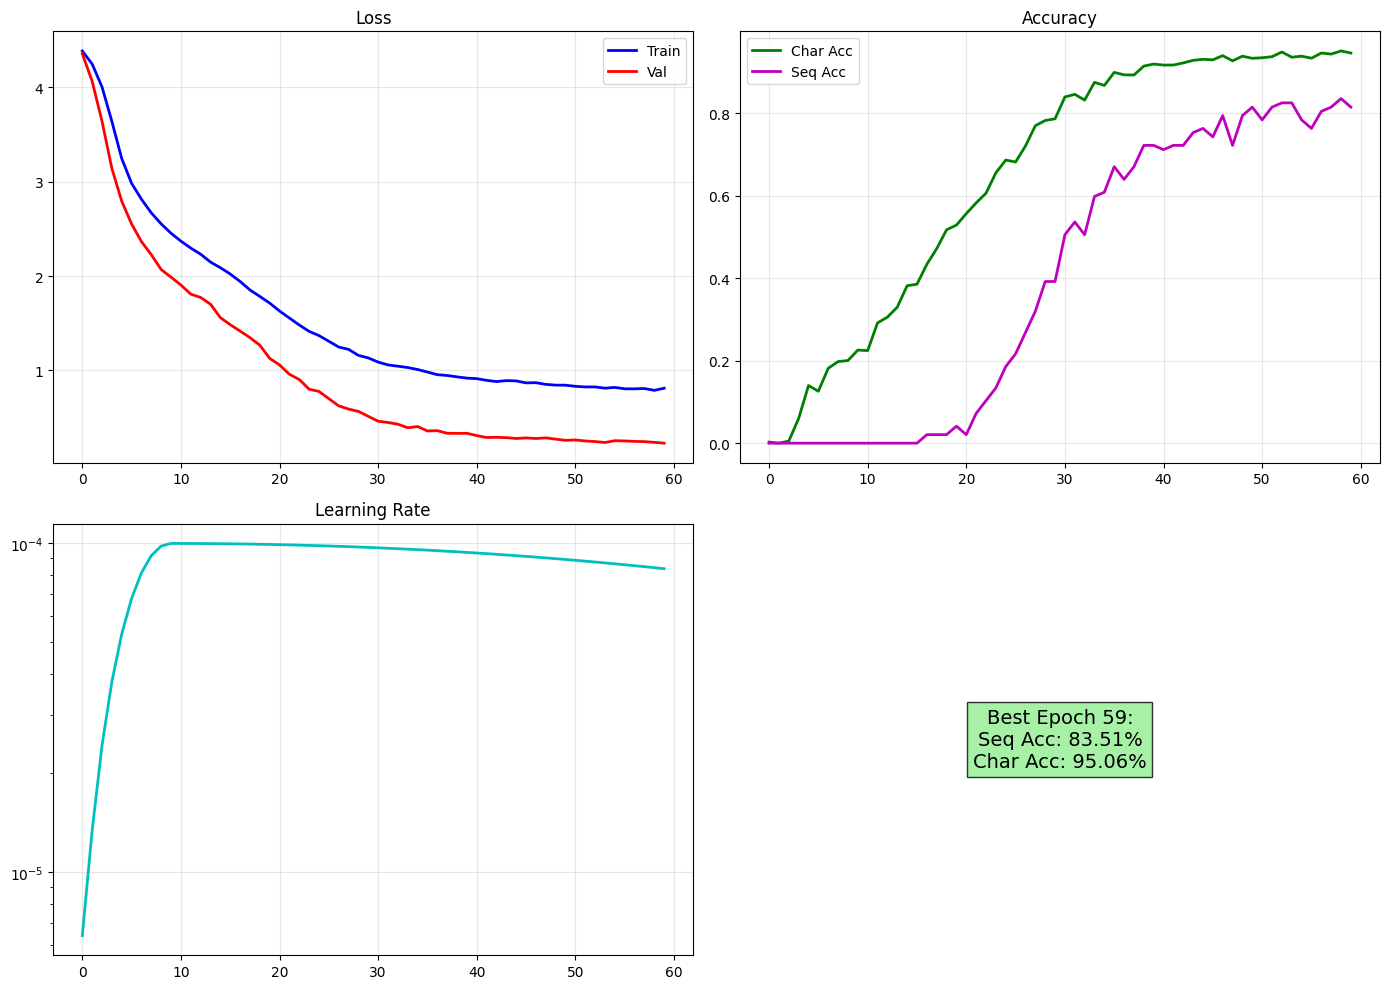


Epoch 61/100


Training:   0%|          | 0/14 [00:00<?, ?it/s]

Validating:   0%|          | 0/2 [00:00<?, ?it/s]

Train Loss: 0.7985 | Val Loss: 0.2370
Char Acc: 94.17% | Seq Acc: 79.38%

Epoch 62/100


Training:   0%|          | 0/14 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/2 [00:00<?, ?it/s]

Train Loss: 0.7713 | Val Loss: 0.2189
Char Acc: 94.68% | Seq Acc: 80.41%

Epoch 80/100


Training:   0%|          | 0/14 [00:00<?, ?it/s]

Validating:   0%|          | 0/2 [00:00<?, ?it/s]

Train Loss: 0.7555 | Val Loss: 0.2157
Char Acc: 94.92% | Seq Acc: 83.51%


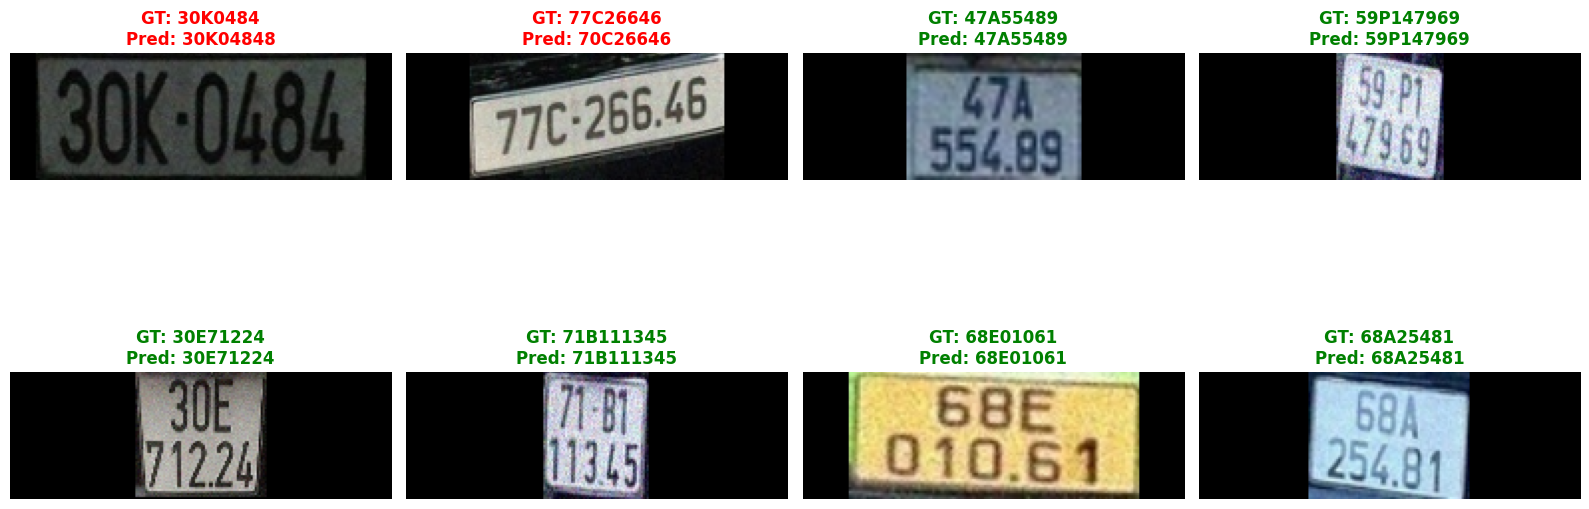

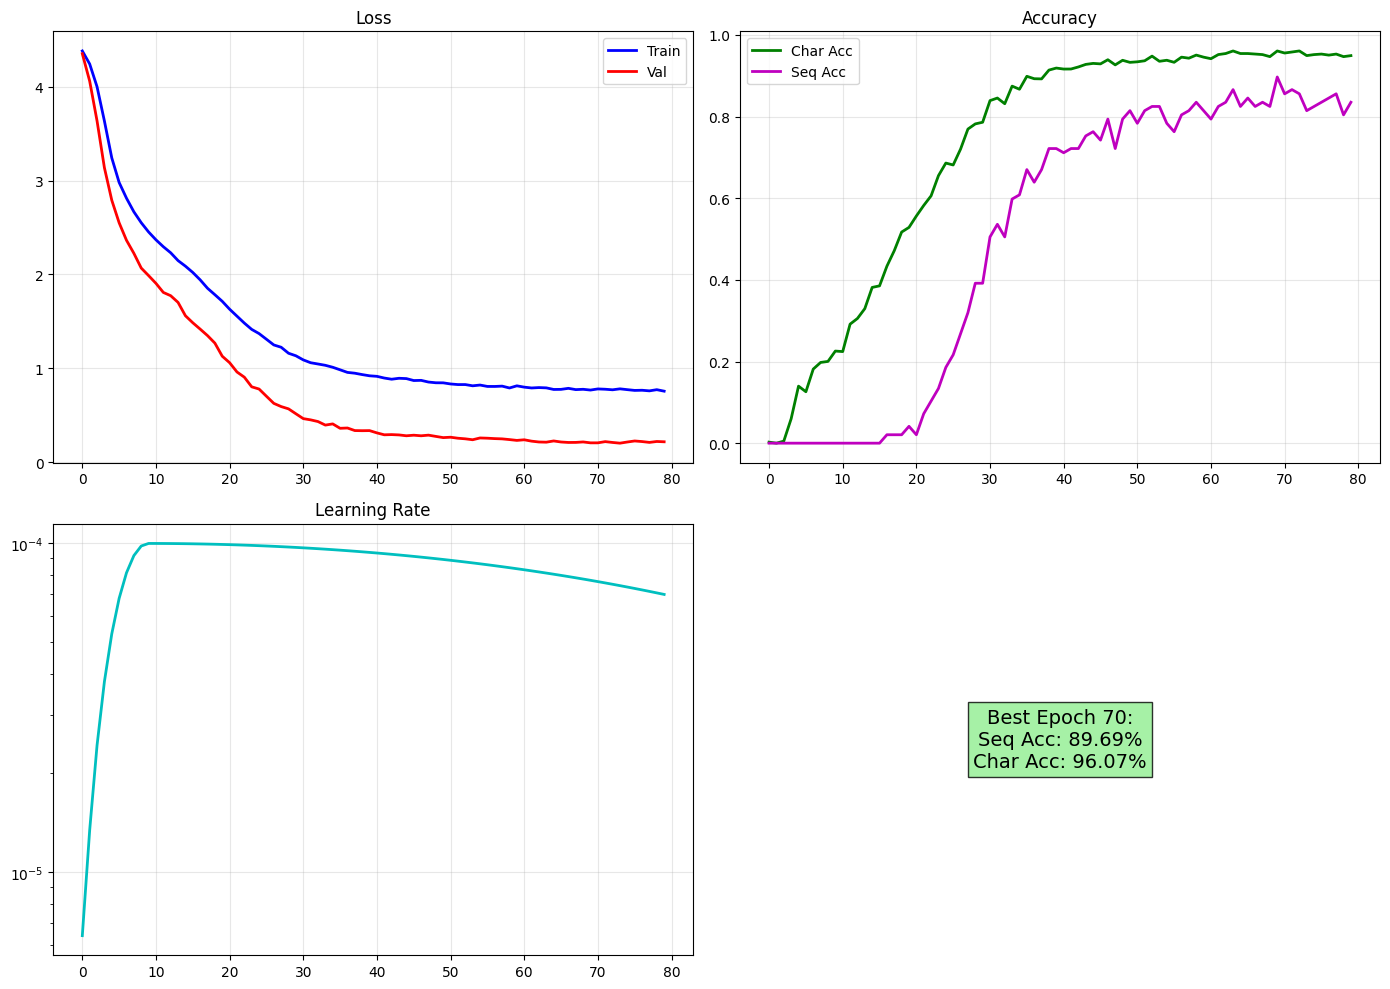


Epoch 81/100


Training:   0%|          | 0/14 [00:00<?, ?it/s]

Validating:   0%|          | 0/2 [00:00<?, ?it/s]

Train Loss: 0.7672 | Val Loss: 0.2151
Char Acc: 95.31% | Seq Acc: 83.51%

Epoch 82/100


Training:   0%|          | 0/14 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/2 [00:00<?, ?it/s]

Train Loss: 0.7516 | Val Loss: 0.2084
Char Acc: 95.94% | Seq Acc: 84.54%

Epoch 90/100


Training:   0%|          | 0/14 [00:00<?, ?it/s]

Validating:   0%|          | 0/2 [00:00<?, ?it/s]

Train Loss: 0.7475 | Val Loss: 0.2110
Char Acc: 95.81% | Seq Acc: 85.57%

Early stopping at epoch 90

Final Results:


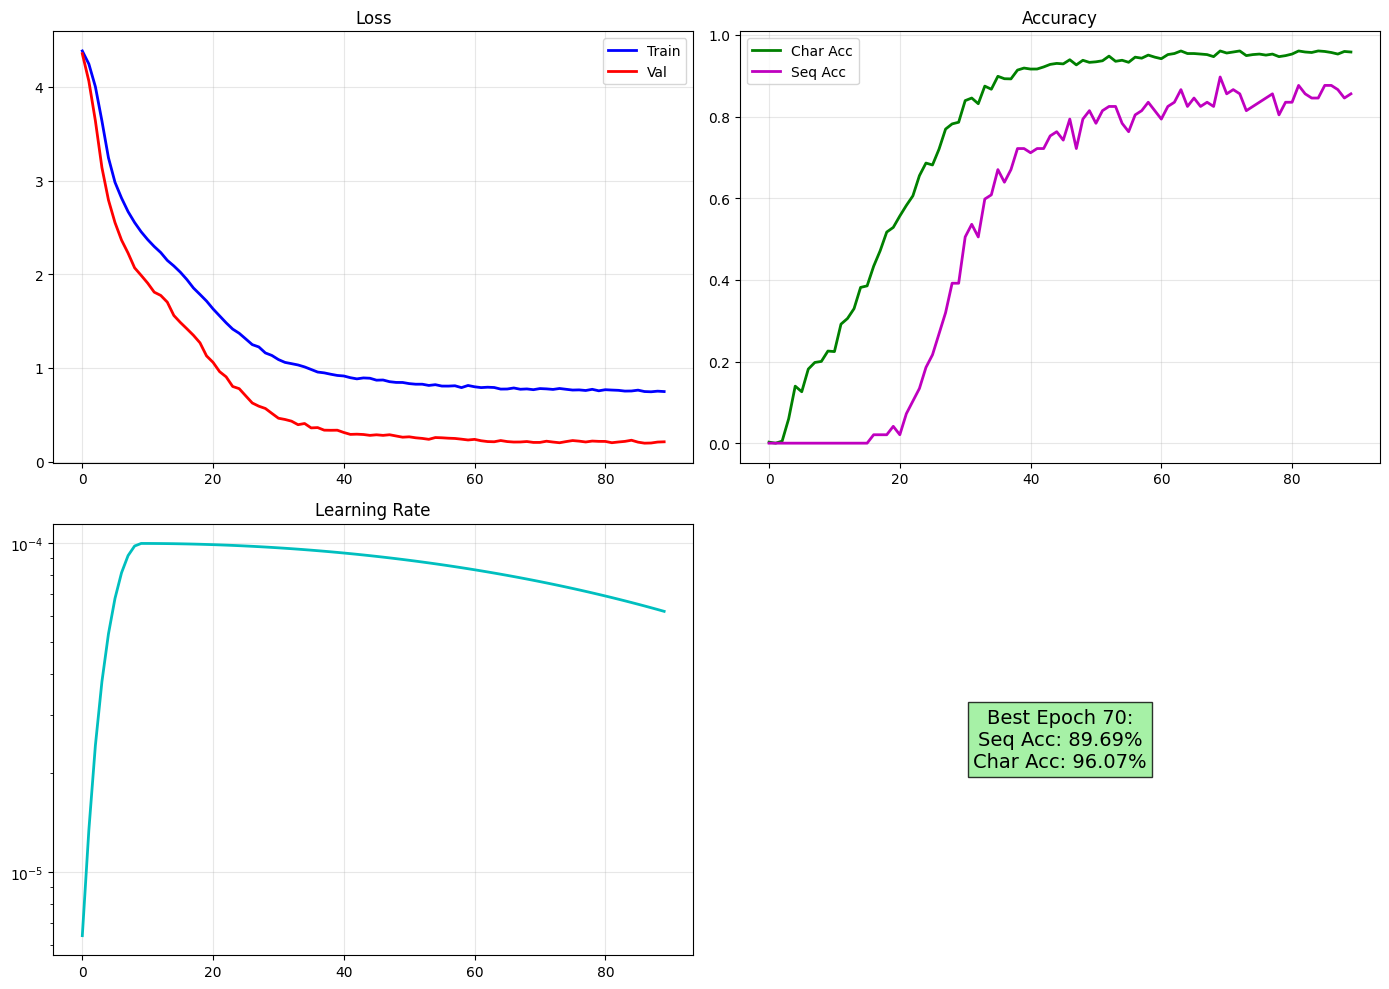

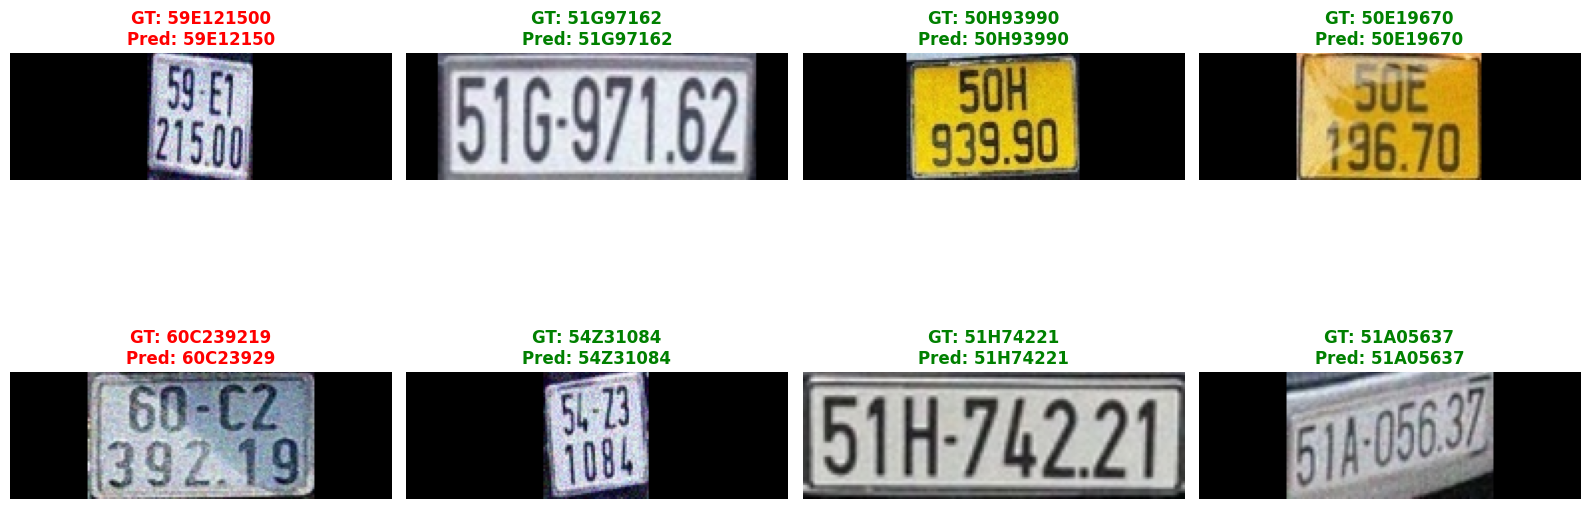


Training complete! Best Seq Acc: 89.69%


In [ ]:
if __name__ == "__main__":
    model, history  = main()